#### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
from collections import Counter

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score

#### Import Datasets

In [2]:
%store -r X_cluster_Scaled
%store -r X_x
%store -r y

X = X_x[["Type", "Rotational speed [rpm]", "Torque [Nm]", "Air temperature [K]", "Process temperature [K]", "Tool wear [min]"]]
X = pd.DataFrame(X) 

In [3]:
X_x.reset_index(drop=True, inplace=True)
y.reset_index(drop=True, inplace=True)

combined_df = pd.concat([X_x, y], axis=1)

print(combined_df.head())

   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     2                298.1                    308.6                    1551   
1     1                298.2                    308.7                    1408   
2     1                298.1                    308.5                    1498   
3     1                298.2                    308.6                    1433   
4     1                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Failure Type  
0         42.8                0             1  
1         46.3                3             1  
2         49.4                5             1  
3         39.5                7             1  
4         40.0                9             1  


#### DBSCAN CLustering

##### Choosing 'eps' and 'min_samples'

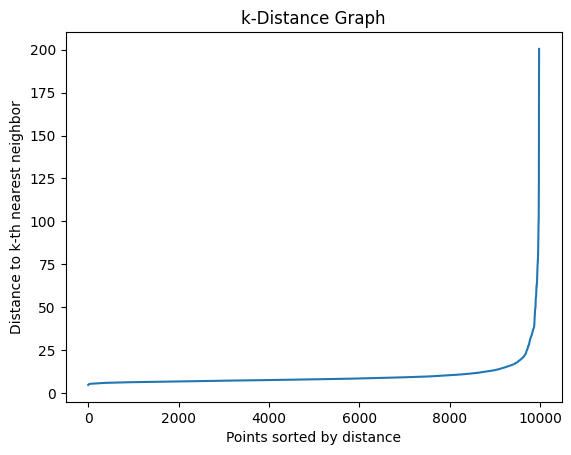

In [11]:
k = 10
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, indices = nbrs.kneighbors(X)
distances = np.sort(distances[:, k-1], axis=0)

plt.plot(distances)
plt.title('k-Distance Graph')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to k-th nearest neighbor')
plt.show()

In [33]:
dbscan_model = DBSCAN(eps=22, min_samples=13)
X['DBSCAN_Cluster'] = dbscan_model.fit_predict(X.drop(columns=['DBSCAN_Cluster'], errors='ignore'))

labels = dbscan_model.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

cluster_counts = Counter(labels)
cluster_counts.pop(-1, None) 

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}\n")

print("Number of samples in each cluster:")
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} samples")

silhouette_dbscan = silhouette_score(X.drop(columns=['DBSCAN_Cluster']), labels)
print(f'\nSilhouette Coefficient: {silhouette_dbscan}')

Number of clusters: 2
Number of noise points: 264

Number of samples in each cluster:
Cluster 0: 9683 samples
Cluster 1: 35 samples

Silhouette Coefficient: 0.5362915645725176


In [34]:
if len(X_x) == len(y):
    X_x['KMeans_Cluster'] = dbscan_model.fit_predict(X_x)

    combined_df = pd.concat([X_x, y.reset_index(drop=True)], axis=1)

    cluster_distribution = combined_df.groupby(['Failure Type', 'KMeans_Cluster']).size().reset_index(name='Count')
    
    print(cluster_distribution)
else:
    print(f"Mismatch in lengths: X_test_Scaled has {len(X_x)} rows, but y_test has {len(y)} rows.")

    Failure Type  KMeans_Cluster  Count
0              0              -1      3
1              0               0    109
2              1              -1    218
3              1               0   9400
4              1               1     34
5              2              -1      5
6              2               0     73
7              3              -1     35
8              3               0     60
9              4              -1      3
10             4               0     41
11             4               1      1


#### Silhouette Coefficient

In [13]:
silhouette_dbscan = silhouette_score(X.drop(columns=['DBSCAN_Cluster']), labels)
print(f'\nSilhouette Coefficient: {silhouette_dbscan}')


Silhouette Coefficient: 0.07512766355995107


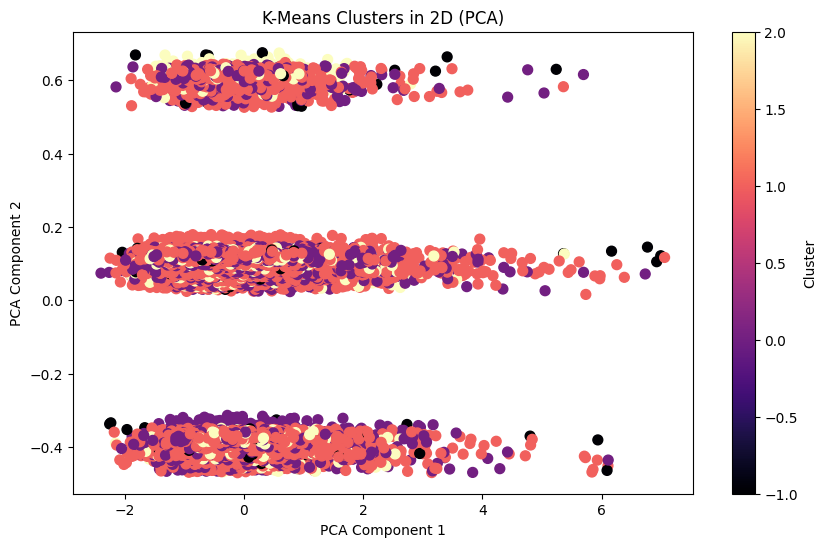

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.drop(columns=['DBSCAN_Cluster']))

X_pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
X_pca_df['DBSCAN_Cluster'] = X['DBSCAN_Cluster']

# Plot PCA results
plt.figure(figsize=(10, 6))
plt.scatter(X_pca_df['PCA1'], X_pca_df['PCA2'], c=X_pca_df['DBSCAN_Cluster'], cmap='magma', s=50)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clusters in 2D (PCA)')
plt.colorbar(label='Cluster')
plt.show()

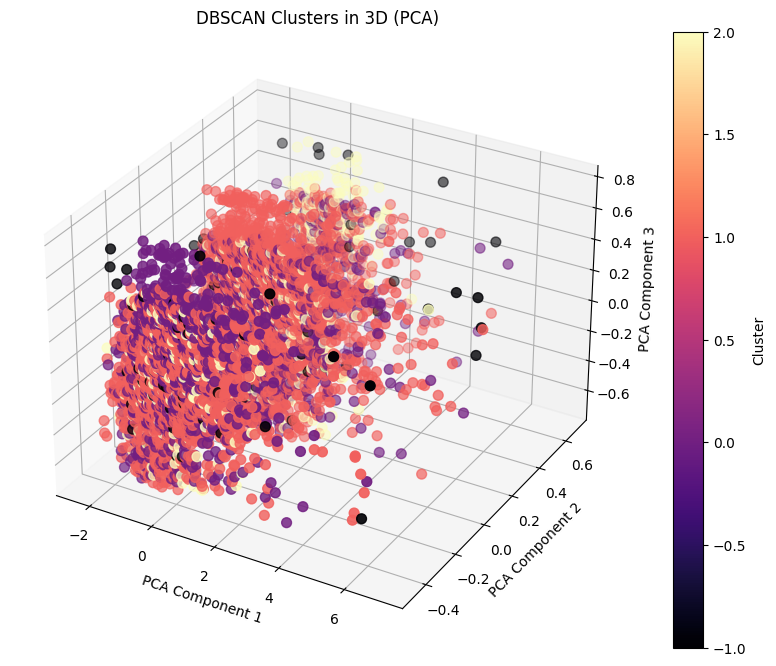

In [10]:
# Apply PCA to reduce to 3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X.drop(columns=['DBSCAN_Cluster']))

# Create a DataFrame with PCA results and cluster labels
X_pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2', 'PCA3'])
X_pca_df['DBSCAN_Cluster'] = X['DBSCAN_Cluster']

# Plot PCA results in 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_df['PCA1'], X_pca_df['PCA2'], X_pca_df['PCA3'],
                     c=X_pca_df['DBSCAN_Cluster'], cmap='magma', s=50)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('DBSCAN Clusters in 3D (PCA)')
fig.colorbar(scatter, label='Cluster')
plt.show()

<Figure size 1000x800 with 0 Axes>

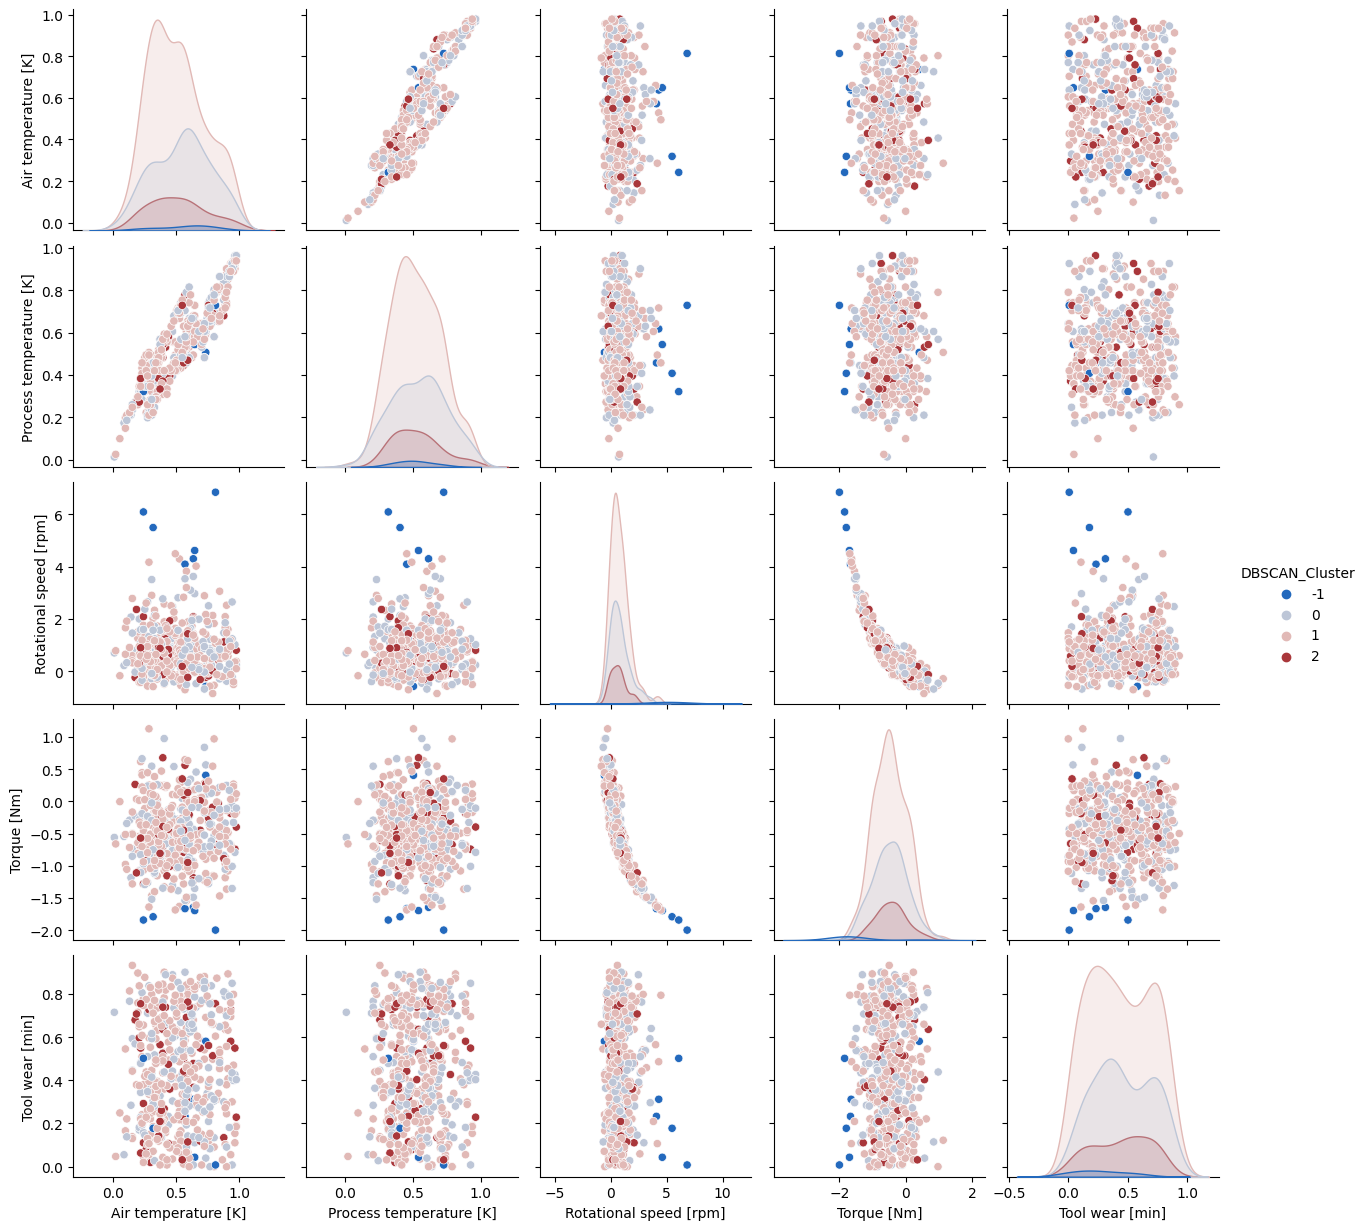

In [11]:
plt.figure(figsize=(10, 8))

sns.pairplot(X.sample(frac=0.05), hue="DBSCAN_Cluster", palette="vlag", vars=["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"])
plt.show()